# Text Preprocessing — Notebook
### AI Engineering Course

This notebook walks through every topic in the Text Preprocessing lecture, with live code demonstrations for each concept.

**Topics covered:**
1. Why preprocess text?
2. Cleaning & normalization
3. Vocabulary operations
4. Word-level tokenization
5. Subword tokenization
6. From text to numbers: BoW, TF-IDF, BM25

In [32]:
# Install dependencies (run once)
# !pip install nltk spacy rank-bm25 scikit-learn transformers beautifulsoup4
# !python -m spacy download en_core_web_sm

import re
import unicodedata
import warnings
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer

import spacy
from bs4 import BeautifulSoup

from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import time

warnings.filterwarnings('ignore')

# Download NLTK data if needed (run once)
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('averaged_perceptron_tagger')

print('Imports ready')

Imports ready


---
## Part 1 — Why preprocess text?

Computers cannot work with raw text directly — they only understand numbers.  
Text is inconsistent, noisy, ambiguous, and variable in length.  
Preprocessing transforms raw text into a clean, standardized form.

In [2]:
# The problem with raw text
examples = [
    "Dog", "dog", "DOG",          # same word, different cases
    "<p>Hello World</p>",          # HTML noise
    "running", "runs", "ran",      # same root, different forms
    "U.S.A. is great",             # abbreviations
    "the", "a", "is",              # stop words — low information
]

print("Raw text examples that a model sees as unrelated:")
for e in examples:
    print(f"  {repr(e)}")

print()
print("After preprocessing, many of these should collapse to the same token.")

Raw text examples that a model sees as unrelated:
  'Dog'
  'dog'
  'DOG'
  '<p>Hello World</p>'
  'running'
  'runs'
  'ran'
  'U.S.A. is great'
  'the'
  'a'
  'is'

After preprocessing, many of these should collapse to the same token.


In [3]:
# Quick illustration: the effect of preprocessing
raw_pairs = [
    ("The dog jumped!!", "dog jump"),
    ("<p>Hello World</p>", "hello world"),
    ("U.S.A. is great", "usa great"),
    ("running, runs, ran", "run run run"),
]

print(f"{'Raw text':<30} {'After preprocessing':<25}")
print("-" * 55)
for raw, clean in raw_pairs:
    print(f"{raw:<30} {clean:<25}")

Raw text                       After preprocessing      
-------------------------------------------------------
The dog jumped!!               dog jump                 
<p>Hello World</p>             hello world              
U.S.A. is great                usa great                
running, runs, ran             run run run              


---
## Part 2 — Cleaning & Normalization

### 2.1 Lowercasing

In [4]:
text = "The Quick Brown Fox Jumps Over the Lazy Dog"
lowercased = text.lower()

print(f"Original : {text}")
print(f"Lowercased: {lowercased}")

# Vocabulary size comparison
tokens_original = set(text.split())
tokens_lower = set(lowercased.split())
print(f"\nUnique tokens before: {len(tokens_original)}")
print(f"Unique tokens after:  {len(tokens_lower)}")

# The exception: case matters sometimes
print("\n⚠️  Case can matter:")
print("  'US' (country) vs 'us' (pronoun)")
print("  'Apple' (company) vs 'apple' (fruit)")

Original : The Quick Brown Fox Jumps Over the Lazy Dog
Lowercased: the quick brown fox jumps over the lazy dog

Unique tokens before: 9
Unique tokens after:  8

⚠️  Case can matter:
  'US' (country) vs 'us' (pronoun)
  'Apple' (company) vs 'apple' (fruit)


### 2.2 Removing punctuation and special characters

In [5]:
text = "Hello, World! This is NLP. Isn't it great? Cost: $99.99"

# Remove all non-word, non-space characters
cleaned = re.sub(r'[^\w\s]', '', text)
print(f"Original : {text}")
print(f"No punct : {cleaned}")

print()
# Sometimes we want to keep certain punctuation
# e.g. hyphens in compound words, apostrophes in contractions
text2 = "state-of-the-art doesn't mean anything without context"
cleaned2 = re.sub(r'[^\w\s\-\']', '', text2)
print(f"Original : {text2}")
print(f"Kept - ' : {cleaned2}")

Original : Hello, World! This is NLP. Isn't it great? Cost: $99.99
No punct : Hello World This is NLP Isnt it great Cost 9999

Original : state-of-the-art doesn't mean anything without context
Kept - ' : state-of-the-art doesn't mean anything without context


### 2.3 Removing HTML, URLs, and noise

In [6]:
# --- HTML tags ---
html_text = "<h1>Product Review</h1><p>This <strong>laptop</strong> is <em>amazing</em>!</p>"
no_html = re.sub(r'<[^>]+>', '', html_text)
print("HTML removal:")
print(f"  Before: {html_text}")
print(f"  After : {no_html}")

HTML removal:
  Before: <h1>Product Review</h1><p>This <strong>laptop</strong> is <em>amazing</em>!</p>
  After : Product ReviewThis laptop is amazing!


In [7]:
# For real HTML, BeautifulSoup is more robust than regex
from bs4 import BeautifulSoup

html = "<div><h2>Best Laptops 2024</h2><p>Check <a href='http://example.com'>this link</a>.</p></div>"
text = BeautifulSoup(html, 'html.parser').get_text(separator=' ')
print("BeautifulSoup:")
print(f"  Before: {html}")
print(f"  After : {text.strip()}")

BeautifulSoup:
  Before: <div><h2>Best Laptops 2024</h2><p>Check <a href='http://example.com'>this link</a>.</p></div>
  After : Best Laptops 2024 Check  this link .


In [8]:
# --- URLs and emails ---
text = "Check out our blog at https://myblog.com/post/123 or www.example.com. Contact: info@company.co.il"
print(f"Original: {text}")

text = re.sub(r'http\S+|www\.\S+', '', text)
print(f"No URLs : {text}")

text = re.sub(r'\S+@\S+', '', text)
print(f"No email: {text}")

text = re.sub(r'\s+', ' ', text).strip()
print(f"Cleaned : {text}")

Original: Check out our blog at https://myblog.com/post/123 or www.example.com. Contact: info@company.co.il
No URLs : Check out our blog at  or  Contact: info@company.co.il
No email: Check out our blog at  or  Contact: 
Cleaned : Check out our blog at or Contact:


In [9]:
# --- Full pipeline on a scraped snippet ---
def remove_noise(text):
    text = re.sub(r'<[^>]+>', ' ', text)       # strip HTML
    text = re.sub(r'http\S+|www\.\S+', '', text) # strip URLs
    text = re.sub(r'\S+@\S+', '', text)          # strip emails
    text = re.sub(r'\s+', ' ', text).strip()     # normalize whitespace
    return text

raw = '<div class="post"><h2>Best Laptops 2024</h2><p>Visit https://techreview.com for details. Contact: editor@techreview.com</p></div>'
print(f"Raw   : {raw}")
print(f"Cleaned: {remove_noise(raw)}")

# text = BeautifulSoup(raw, 'html.parser').get_text(separator=' ')
# print(f"Text  : {text}")


Raw   : <div class="post"><h2>Best Laptops 2024</h2><p>Visit https://techreview.com for details. Contact: editor@techreview.com</p></div>
Cleaned: Best Laptops 2024 Visit for details. Contact:


### 2.4 Handling numbers — three strategies

In [10]:
text = "On January 5th 2024, the temperature was -3 degrees and 12 people attended"

# Strategy 1: remove entirely
s1 = re.sub(r'\d+', '', text)
s1 = re.sub(r'\s+', ' ', s1).strip()
print(f"Original        : {text}")
print(f"Strategy 1 (rm) : {s1}")

# Strategy 2: replace with placeholder
s2 = re.sub(r'\d+\.\d+', '<FLOAT>', text)
s2 = re.sub(r'\d+', '<INT>', s2)
print(f"Strategy 2 (<INT>): {s2}")

# Strategy 3: keep as-is, just normalize formatting
text_financial = "Revenue was $1,234,567 in Q3, up 12.5%"
s3 = text_financial.replace(',', '').replace('$', '').replace('%', ' percent')
print(f"\nFinancial original: {text_financial}")
print(f"Strategy 3 (keep) : {s3}")

Original        : On January 5th 2024, the temperature was -3 degrees and 12 people attended
Strategy 1 (rm) : On January th , the temperature was - degrees and people attended
Strategy 2 (<INT>): On January <INT>th <INT>, the temperature was -<INT> degrees and <INT> people attended

Financial original: Revenue was $1,234,567 in Q3, up 12.5%
Strategy 3 (keep) : Revenue was 1234567 in Q3 up 12.5 percent


In [11]:
# When to use which strategy
strategies = {
    "Remove entirely": "Sentiment analysis — '5-star hotel was amazing' → star rating redundant",
    "Replace <NUM>": "NER — 'room 42' → model learns '<NUM>' is a location pattern",
    "Keep as-is": "Finance — 'stock fell 12%' vs 'stock fell 40%' — magnitude matters",
}
for strategy, example in strategies.items():
    print(f"{strategy:>20}: {example}")

     Remove entirely: Sentiment analysis — '5-star hotel was amazing' → star rating redundant
       Replace <NUM>: NER — 'room 42' → model learns '<NUM>' is a location pattern
          Keep as-is: Finance — 'stock fell 12%' vs 'stock fell 40%' — magnitude matters


### 2.5 Unicode normalization

In [12]:
import unicodedata

# The same character encoded two different ways
e_composed   = '\u00e9'          # é as a single codepoint (NFC)
e_decomposed = 'e\u0301'         # é as e + combining accent (NFD)

print(f"Composed   : {e_composed!r}  → renders as: {e_composed}")
print(f"Decomposed : {e_decomposed!r} → renders as: {e_decomposed}")
print(f"They look the same: {e_composed == e_decomposed}")  # False!
print()

# NFC: normalize to composed form — one canonical form for storage/comparison
normalized = unicodedata.normalize('NFC', e_decomposed)
print(f"After NFC: {normalized!r} → renders as: {normalized}")
print(f"Now equal: {e_composed == normalized}")

Composed   : 'é'  → renders as: é
Decomposed : 'é' → renders as: é
They look the same: False

After NFC: 'é' → renders as: é
Now equal: True


In [13]:
# Stripping accents: NFD decompose, then drop combining marks (category 'Mn')
text = "café résumé naïve Ångström"

def strip_accents(text):
    text = unicodedata.normalize('NFD', text)            # decompose
    text = ''.join(c for c in text                       # drop Mark, Nonspacing
                   if unicodedata.category(c) != 'Mn')
    return text

print(f"Original      : {text}")
print(f"Accents stripped: {strip_accents(text)}")

Original      : café résumé naïve Ångström
Accents stripped: cafe resume naive Angstrom


In [14]:
# Hebrew example with nikud
# Note: Hebrew with nikud is already in decomposed form (NFD), so no composed vs decomposed issue like Latin
hebrew_nikud = '\u05d0\u05b8'  # אָ (alef with kamatz) - already NFD

print(f"Hebrew nikud: {hebrew_nikud!r}  → renders as: {hebrew_nikud}")

# Normalization doesn't change it
normalized_hebrew = unicodedata.normalize('NFC', hebrew_nikud)
print(f"After NFC: {normalized_hebrew!r}")
print(f"Unchanged: {hebrew_nikud == normalized_hebrew}")  # True - already normalized

Hebrew nikud: 'אָ'  → renders as: אָ
After NFC: 'אָ'
Unchanged: True


In [15]:
# Removing nikud from Hebrew text
# Define the strip_accents function (removes all combining marks)
def strip_accents(text):
    import unicodedata
    text = unicodedata.normalize('NFD', text)            # decompose
    text = ''.join(c for c in text                       # drop Mark, Nonspacing
                   if unicodedata.category(c) != 'Mn')
    return text

hebrew_with_nikud = "אָבִי אֹהֵב אוֹתְךָ"  # "avi ohev otcha" with nikud
hebrew_without_nikud = strip_accents(hebrew_with_nikud)

print(f"With nikud   : {hebrew_with_nikud}")
print(f"Without nikud: {hebrew_without_nikud}")

# Alternative: regex to remove specific nikud ranges (U+0591 to U+05C7)
import re
def remove_nikud_regex(text):
    # Remove Hebrew nikud (points) and cantillation marks
    nikud_pattern = r'[\u0591-\u05C7]'
    return re.sub(nikud_pattern, '', text)

print(f"Regex result : {remove_nikud_regex(hebrew_with_nikud)}")

With nikud   : אָבִי אֹהֵב אוֹתְךָ
Without nikud: אבי אהב אותך
Regex result : אבי אהב אותך


In [16]:
# Other invisible Unicode noise from PDFs and Word docs
messy = "\u201cHello\u201d he said\u2014 and left. Price\u00a0was\u00a0$10."
print(f"Messy  : {messy!r}")
print(f"Display: {messy}")

def normalize_unicode(text):
    text = text.replace('\u201c', '"').replace('\u201d', '"')  # smart quotes
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    text = text.replace('\u2014', '-').replace('\u2013', '-')  # em/en dash
    text = text.replace('\u00a0', ' ')                          # non-breaking space
    text = unicodedata.normalize('NFC', text)
    return text

clean = normalize_unicode(messy)
print(f"\nCleaned: {clean!r}")
print(f"Display: {clean}")

Messy  : '“Hello” he said— and left. Price\xa0was\xa0$10.'
Display: “Hello” he said— and left. Price was $10.

Cleaned: '"Hello" he said- and left. Price was $10.'
Display: "Hello" he said- and left. Price was $10.


### 2.6 The full cleaning pipeline

In [17]:
def clean_text(text, remove_numbers=True):
    """Full text cleaning pipeline."""
    # 1. Normalize unicode
    text = normalize_unicode(text)
    # 2. Strip HTML
    text = re.sub(r'<[^>]+>', ' ', text)
    # 3. Strip URLs and emails
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    # 4. Lowercase
    text = text.lower()
    # 5. Handle numbers
    if remove_numbers:
        text = re.sub(r'\d+', '', text)
    # 6. Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # 7. Strip extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

sample = '<p>Check out https://example.com! <strong>Amazing</strong> deal\u2014only $29.99 on Jan 5th 2024.</p>'
print(f"Raw    : {sample}")
print(f"Cleaned: {clean_text(sample)}")

Raw    : <p>Check out https://example.com! <strong>Amazing</strong> deal—only $29.99 on Jan 5th 2024.</p>
Cleaned: check out amazing dealonly on jan th


---
## Part 3 — Vocabulary Operations

### 3.1 Stop words

In [18]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
print(f"Number of English stop words: {len(stop_words)}")
print(f"Sample: {sorted(list(stop_words))[:20]}")

Number of English stop words: 198
Sample: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [19]:
text = "The cat sat on the mat and looked at the window"
tokens = text.lower().split()

filtered = [t for t in tokens if t not in stop_words]

print(f"Original tokens : {tokens}")
print(f"Without stops   : {filtered}")
print(f"Tokens removed  : {[t for t in tokens if t in stop_words]}")

print()
# Warning: 'not' is a stop word — can break sentiment analysis
text2 = "this movie is not good at all"
tokens2 = text2.split()
filtered2 = [t for t in tokens2 if t not in stop_words]
print(f"⚠️  Sentiment risk:")
print(f"  Original : {tokens2}")
print(f"  Filtered : {filtered2}  ← 'not' removed, meaning flipped!")

Original tokens : ['the', 'cat', 'sat', 'on', 'the', 'mat', 'and', 'looked', 'at', 'the', 'window']
Without stops   : ['cat', 'sat', 'mat', 'looked', 'window']
Tokens removed  : ['the', 'on', 'the', 'and', 'at', 'the']

⚠️  Sentiment risk:
  Original : ['this', 'movie', 'is', 'not', 'good', 'at', 'all']
  Filtered : ['movie', 'good']  ← 'not' removed, meaning flipped!


In [20]:
# Removing stop words but keeping negatives (like 'not')
# Create custom stop words list excluding negation words

negation_words = {'not', 'no', 'never', 'none', 'neither', 'nor', 'nothing', 'nobody', 'nowhere'}
custom_stop_words = stop_words - negation_words  # remove negatives from stop list

print(f"Original stop words: {len(stop_words)}")
print(f"Custom stop words : {len(custom_stop_words)} (excluded {len(negation_words)} negatives)")
print(f"Excluded negatives: {sorted(negation_words)}")

# Test on sentiment text
text_sentiment = "this movie is not good at all, it is never boring"
tokens_sentiment = text_sentiment.lower().split()

# Standard filtering (removes 'not' and 'never')
filtered_standard = [t for t in tokens_sentiment if t not in stop_words]

# Custom filtering (keeps negatives)
filtered_custom = [t for t in tokens_sentiment if t not in custom_stop_words]

print(f"\nOriginal tokens    : {tokens_sentiment}")
print(f"Standard filtering : {filtered_standard}  ← sentiment flipped!")
print(f"Custom filtering   : {filtered_custom}     ← sentiment preserved ✓")

Original stop words: 198
Custom stop words : 195 (excluded 9 negatives)
Excluded negatives: ['neither', 'never', 'no', 'nobody', 'none', 'nor', 'not', 'nothing', 'nowhere']

Original tokens    : ['this', 'movie', 'is', 'not', 'good', 'at', 'all,', 'it', 'is', 'never', 'boring']
Standard filtering : ['movie', 'good', 'all,', 'never', 'boring']  ← sentiment flipped!
Custom filtering   : ['movie', 'not', 'good', 'all,', 'never', 'boring']     ← sentiment preserved ✓


### 3.2 Stemming

In [21]:
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.stem.regexp import RegexpStemmer

words = ["running", "runner", "runs", "ran",
         "studies", "studying", "studied",
         "easily", "fairly", "happiness"]

porter = PorterStemmer()
snowball = SnowballStemmer('english')
regexp = RegexpStemmer('ing$|s$|ed$', min=4)  # simple custom rules

print(f"{'Word':<15} {'Porter':<15} {'Snowball':<15} {'Regexp':<15}")
print("-" * 60)
for word in words:
    print(f"{word:<15} {porter.stem(word):<15} {snowball.stem(word):<15} {regexp.stem(word):<15}")

Word            Porter          Snowball        Regexp         
------------------------------------------------------------
running         run             run             runn           
runner          runner          runner          runner         
runs            run             run             run            
ran             ran             ran             ran            
studies         studi           studi           studie         
studying        studi           studi           study          
studied         studi           studi           studi          
easily          easili          easili          easily         
fairly          fairli          fair            fairly         
happiness       happi           happi           happines       


In [22]:
# Snowball supports multiple languages
print("Snowball supported languages:", SnowballStemmer.languages)

# Example: French stemming
fr_stemmer = SnowballStemmer('french')
french_words = ["chanter", "chanteur", "chantons", "mangeons", "manger"]
print()
print("French stemming:")
for w in french_words:
    print(f"  {w} → {fr_stemmer.stem(w)}")

Snowball supported languages: ('arabic', 'danish', 'dutch', 'english', 'finnish', 'french', 'german', 'hungarian', 'italian', 'norwegian', 'porter', 'portuguese', 'romanian', 'russian', 'spanish', 'swedish')

French stemming:
  chanter → chant
  chanteur → chanteur
  chantons → chanton
  mangeons → mangeon
  manger → mang


### 3.3 Lemmatization

In [23]:
import spacy

In [24]:
import spacy
nlp = spacy.load('en_core_web_sm')

text = "The children were running quickly and the geese flew better than before"
doc = nlp(text)

print(f"{'Token':<15} {'Lemma':<15} {'POS':<10}")
print("-" * 40)
for token in doc:
    print(f"{token.text:<15} {token.lemma_:<15} {token.pos_:<10}")

Token           Lemma           POS       
----------------------------------------
The             the             DET       
children        child           NOUN      
were            be              AUX       
running         run             VERB      
quickly         quickly         ADV       
and             and             CCONJ     
the             the             DET       
geese           geese           PROPN     
flew            fly             VERB      
better          well            ADV       
than            than            ADP       
before          before          ADP       


In [25]:
# Stemming vs Lemmatization: direct comparison
import spacy
from nltk.stem import PorterStemmer

nlp = spacy.load('en_core_web_sm')
porter = PorterStemmer()

words = ["better", "was", "children", "geese", "running", "studies"]

print(f"{'Word':<12} {'Porter stem':<15} {'Lemma (spaCy)':<15}")
print("-" * 42)
for word in words:
    doc = nlp(word)
    lemma = doc[0].lemma_
    stem = porter.stem(word)
    print(f"{word:<12} {stem:<15} {lemma:<15}")

print()
print("Key differences:")
print("  'better' → stemmer keeps it, lemmatizer gives 'good'")
print("  'was'    → stemmer gives 'wa', lemmatizer gives 'be'")
print("  'geese'  → stemmer gives 'gees', lemmatizer gives 'goose'")

Word         Porter stem     Lemma (spaCy)  
------------------------------------------
better       better          well           
was          wa              be             
children     children        child          
geese        gees            geese          
running      run             run            
studies      studi           study          

Key differences:
  'better' → stemmer keeps it, lemmatizer gives 'good'
  'was'    → stemmer gives 'wa', lemmatizer gives 'be'
  'geese'  → stemmer gives 'gees', lemmatizer gives 'goose'


### 3.4 N-grams

In [26]:
from nltk import ngrams

tokens = ["I", "love", "natural", "language", "processing"]

for n in [1, 2, 3]:
    name = {1: "Unigrams", 2: "Bigrams", 3: "Trigrams"}[n]
    grams = list(ngrams(tokens, n))
    print(f"{name}: {grams}")

Unigrams: [('I',), ('love',), ('natural',), ('language',), ('processing',)]
Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing')]


In [27]:
# Why bigrams matter: negation and compound concepts
examples = [
    ("not good", "bigram captures negation; unigram loses it"),
    ("New York", "two words, one concept"),
    ("machine learning", "compound concept split by unigrams"),
]

for phrase, reason in examples:
    words = phrase.split()
    unigrams = words
    bigram = [" ".join(words)]
    print(f"Phrase: '{phrase}'")
    print(f"  Unigrams: {unigrams}")
    print(f"  Bigram  : {bigram}  ← {reason}")
    print()

Phrase: 'not good'
  Unigrams: ['not', 'good']
  Bigram  : ['not good']  ← bigram captures negation; unigram loses it

Phrase: 'New York'
  Unigrams: ['New', 'York']
  Bigram  : ['New York']  ← two words, one concept

Phrase: 'machine learning'
  Unigrams: ['machine', 'learning']
  Bigram  : ['machine learning']  ← compound concept split by unigrams



---
## Part 4 — Word-level Tokenization

### 4.1 What is a token?

In [28]:
# Simple whitespace tokenization
text = "I love NLP"
tokens = text.split()
print(f"Text  : '{text}'")
print(f"Tokens: {tokens}")
print(f"Count : {len(tokens)} tokens")

Text  : 'I love NLP'
Tokens: ['I', 'love', 'NLP']
Count : 3 tokens


### 4.2 Building a vocabulary and assigning token IDs

In [29]:
corpus = [
    "The quick brown fox",
    "The fox jumped over the lazy dog",
    "Dogs and foxes are animals",
]

# Tokenize and build vocabulary
all_tokens = []
for doc in corpus:
    all_tokens.extend(doc.lower().split())

vocab = sorted(set(all_tokens))  # alphabetical order
word2id = {word: idx for idx, word in enumerate(vocab)}
id2word = {idx: word for word, idx in word2id.items()}

print("Vocabulary (word → ID):")
for word, idx in word2id.items():
    print(f"  {word:<12} → {idx}")

Vocabulary (word → ID):
  and          → 0
  animals      → 1
  are          → 2
  brown        → 3
  dog          → 4
  dogs         → 5
  fox          → 6
  foxes        → 7
  jumped       → 8
  lazy         → 9
  over         → 10
  quick        → 11
  the          → 12


In [8]:
# Encode and decode
def encode(text, word2id, unk_id):
    return [word2id.get(t, unk_id) for t in text.lower().split()]

def decode(ids, id2word):
    return [id2word.get(i, '<UNK>') for i in ids]

UNK_ID = len(word2id)  # next available ID

test = "the quick fox jumped"
encoded = encode(test, word2id, UNK_ID)
decoded = decode(encoded, id2word)

print(f"Text   : {test}")
print(f"Encoded: {encoded}")
print(f"Decoded: {decoded}")

Text   : the quick fox jumped
Encoded: [12, 11, 6, 8]
Decoded: ['the', 'quick', 'fox', 'jumped']


### 4.3 Special tokens

In [9]:
# Special tokens extend the vocabulary
special_tokens = {
    '<UNK>': 'Unknown word — not in vocabulary',
    '<PAD>': 'Padding — make sequences equal length',
    '<BOS>': 'Beginning of sequence',
    '<EOS>': 'End of sequence',
    '<CLS>': 'Classification token (BERT-style)',
    '<SEP>': 'Separator between segments (BERT-style)',
    '<MASK>': 'Masked token for MLM pre-training',
    '<|endoftext|>': 'GPT-style end-of-document marker',
}

print(f"{'Token':<20} {'Purpose'}")
print("-" * 60)
for token, purpose in special_tokens.items():
    print(f"{token:<20} {purpose}")

Token                Purpose
------------------------------------------------------------
<UNK>                Unknown word — not in vocabulary
<PAD>                Padding — make sequences equal length
<BOS>                Beginning of sequence
<EOS>                End of sequence
<CLS>                Classification token (BERT-style)
<SEP>                Separator between segments (BERT-style)
<MASK>               Masked token for MLM pre-training
<|endoftext|>        GPT-style end-of-document marker


In [10]:
# Padding example: making variable-length sequences equal
sequences = [
    [4, 7, 2],
    [1, 9],
    [3, 5, 8, 6, 2],
]

PAD_ID = 0
max_len = max(len(s) for s in sequences)
padded = [s + [PAD_ID] * (max_len - len(s)) for s in sequences]

print("Before padding:", sequences)
print("After padding :", padded)
print(f"All length {max_len} — ready for batch processing")

Before padding: [[4, 7, 2], [1, 9], [3, 5, 8, 6, 2]]
After padding : [[4, 7, 2, 0, 0], [1, 9, 0, 0, 0], [3, 5, 8, 6, 2]]
All length 5 — ready for batch processing


### 4.4 Word tokenization challenges

In [15]:
# NLTK word tokenizer handles many edge cases
nltk.download('punkt', quiet=True)
from nltk.tokenize import word_tokenize

challenges = [
    "don't can't won't",           # contractions
    "state-of-the-art",             # hyphenated
    "end.",                         # punctuation attached
    "U.S.A. is great.",             # abbreviations with periods
    "$100.50 or €200",              # currency
]

print(f"{'Input':<30} {'Tokens'}")
print("-" * 70)
for text in challenges:
    tokens = word_tokenize(text)
    print(f"{text:<30} {tokens}")

Input                          Tokens
----------------------------------------------------------------------
don't can't won't              ['do', "n't", 'ca', "n't", 'wo', "n't"]
state-of-the-art               ['state-of-the-art']
end.                           ['end', '.']
U.S.A. is great.               ['U.S.A.', 'is', 'great', '.']
$100.50 or €200                ['$', '100.50', 'or', '€200']


### 4.5 Sentence tokenization

In [16]:
from nltk.tokenize import sent_tokenize

# The tricky cases — periods inside sentences
text = "Dr. Smith went to Washington D.C. He loved it. The U.S. govt paid $1.5M."
sentences = sent_tokenize(text)

print(f"Input: {text}")
print()
print("Sentences detected:")
for i, s in enumerate(sentences, 1):
    print(f"  {i}. {s}")

Input: Dr. Smith went to Washington D.C. He loved it. The U.S. govt paid $1.5M.

Sentences detected:
  1. Dr. Smith went to Washington D.C.
  2. He loved it.
  3. The U.S. govt paid $1.5M.


### 4.6 Character-level tokenization

In [17]:
word = "hello"
char_tokens = list(word)
print(f"Word: '{word}'")
print(f"Character tokens: {char_tokens}")
print(f"Vocabulary size: just {len(set(char_tokens))} unique characters")

print()
# Advantage: handles ANY word, including misspellings
words = ["hello", "helo", "h3ll0", "superkalafragalisticexpialidocious"]
for w in words:
    chars = list(w)
    print(f"  '{w}' → {chars[:8]}{'...' if len(chars) > 8 else ''}  ({len(chars)} chars)")

print()
print("Trade-off: sequences become very long — 'hello' is 5 tokens instead of 1")

Word: 'hello'
Character tokens: ['h', 'e', 'l', 'l', 'o']
Vocabulary size: just 4 unique characters

  'hello' → ['h', 'e', 'l', 'l', 'o']  (5 chars)
  'helo' → ['h', 'e', 'l', 'o']  (4 chars)
  'h3ll0' → ['h', '3', 'l', 'l', '0']  (5 chars)
  'superkalafragalisticexpialidocious' → ['s', 'u', 'p', 'e', 'r', 'k', 'a', 'l']...  (34 chars)

Trade-off: sequences become very long — 'hello' is 5 tokens instead of 1


---
## Part 5 — Subword Tokenization

### 5.1 The OOV problem with word-level tokenizers

In [18]:
# Simulate a word-level tokenizer with a fixed training vocabulary
training_vocab = {"the", "cat", "sat", "on", "mat", "dog", "chased", "happy", "sad"}
UNK = "<UNK>"

def word_tokenize_with_unk(text, vocab):
    return [t if t in vocab else UNK for t in text.lower().split()]

# Inference-time sentences with unseen words
test_sentences = [
    "the cat sat on the mat",            # all known
    "the cryptocurrency crashed overnight", # 'cryptocurrency' unknown
    "dogecoin blockchain nft crashed",      # all financial jargon = all UNK
]

for sent in test_sentences:
    tokens = word_tokenize_with_unk(sent, training_vocab)
    print(f"Input  : {sent}")
    print(f"Tokens : {tokens}")
    unk_count = tokens.count(UNK)
    if unk_count > 0:
        print(f"⚠️  {unk_count} word(s) lost to <UNK>")
    print()

Input  : the cat sat on the mat
Tokens : ['the', 'cat', 'sat', 'on', 'the', 'mat']

Input  : the cryptocurrency crashed overnight
Tokens : ['the', '<UNK>', '<UNK>', '<UNK>']
⚠️  3 word(s) lost to <UNK>

Input  : dogecoin blockchain nft crashed
Tokens : ['<UNK>', '<UNK>', '<UNK>', '<UNK>']
⚠️  4 word(s) lost to <UNK>



### 5.2 Subword tokenization with a real tokenizer (BPE — GPT-2)

In [19]:
from transformers import GPT2Tokenizer, BertTokenizer

gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print(f"GPT-2 vocabulary size : {gpt2_tokenizer.vocab_size:,}")
print(f"BERT vocabulary size  : {bert_tokenizer.vocab_size:,}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

GPT-2 vocabulary size : 50,257
BERT vocabulary size  : 30,522


In [20]:
# BPE (GPT-2) — how it handles various words
words = [
    "tokenization",
    "unhappiness",
    "cryptocurrency",
    "Akwirwier",           # completely made-up word
    "1234",
    "12345",
    "12346",
]

print("GPT-2 BPE tokenization:")
print(f"{'Word':<20} {'Tokens':<40} {'Count'}")
print("-" * 65)
for word in words:
    token_ids = gpt2_tokenizer.encode(word)
    token_strs = gpt2_tokenizer.convert_ids_to_tokens(token_ids)
    print(f"{word:<20} {str(token_strs):<40} {len(token_strs)}")

GPT-2 BPE tokenization:
Word                 Tokens                                   Count
-----------------------------------------------------------------
tokenization         ['token', 'ization']                     2
unhappiness          ['un', 'h', 'appiness']                  3
cryptocurrency       ['crypt', 'oc', 'urrency']               3
Akwirwier            ['Ak', 'w', 'ir', 'w', 'ier']            5
1234                 ['12', '34']                             2
12345                ['123', '45']                            2
12346                ['12', '346']                            2


In [21]:
# BERT WordPiece — note the ## prefix on continuation subwords
print("BERT WordPiece tokenization:")
print(f"{'Word':<20} {'Tokens':<40} {'Count'}")
print("-" * 65)
for word in words:
    tokens = bert_tokenizer.tokenize(word)
    print(f"{word:<20} {str(tokens):<40} {len(tokens)}")

print()
print("Note: ## prefix = continuation subword (not word-initial)")

BERT WordPiece tokenization:
Word                 Tokens                                   Count
-----------------------------------------------------------------
tokenization         ['token', '##ization']                   2
unhappiness          ['un', '##ha', '##pp', '##iness']        4
cryptocurrency       ['crypt', '##oc', '##ur', '##ren', '##cy'] 5
Akwirwier            ['ak', '##wi', '##r', '##wi', '##er']    5
1234                 ['123', '##4']                           2
12345                ['123', '##45']                          2
12346                ['123', '##46']                          2

Note: ## prefix = continuation subword (not word-initial)


In [22]:
# Numbers: inconsistent tokenization — the core problem
print("Number tokenization (GPT-2) — notice the arbitrary splits:")
numbers = [str(n) for n in [1, 12, 123, 1234, 12345, 12346, 99, 100, 101, 1000, 1001]]
for n in numbers:
    tokens = gpt2_tokenizer.convert_ids_to_tokens(gpt2_tokenizer.encode(n))
    print(f"  {n:<8} → {tokens}")

print()
print("Consequence: '1000' and '1001' may have completely different subword representations.")
print("The model has no built-in sense of numeric proximity or magnitude.")

Number tokenization (GPT-2) — notice the arbitrary splits:
  1        → ['1']
  12       → ['12']
  123      → ['123']
  1234     → ['12', '34']
  12345    → ['123', '45']
  12346    → ['12', '346']
  99       → ['99']
  100      → ['100']
  101      → ['101']
  1000     → ['1000']
  1001     → ['1001']

Consequence: '1000' and '1001' may have completely different subword representations.
The model has no built-in sense of numeric proximity or magnitude.


### 5.3 BPE training algorithm (step by step)

In [23]:
from collections import Counter, defaultdict

def get_pairs(vocab):
    """Count all adjacent symbol pairs in the vocabulary."""
    pairs = Counter()
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i+1])] += freq
    return pairs

def merge_pair(pair, vocab):
    """Merge all occurrences of a pair into a single symbol."""
    new_vocab = {}
    bigram = ' '.join(pair)
    replacement = ''.join(pair)
    for word, freq in vocab.items():
        new_word = word.replace(bigram, replacement)
        new_vocab[new_word] = freq
    return new_vocab

# Small training corpus — each word split into chars, with </w> marking word-end
vocab = {
    'l o w </w>': 5,
    'l o w e r </w>': 2,
    'n e w e s t </w>': 6,
    'w i d e s t </w>': 3,
}

print("Initial vocabulary:")
for word, freq in vocab.items():
    print(f"  {word!r:30} freq={freq}")

print()
num_merges = 8
merges = []

for i in range(num_merges):
    pairs = get_pairs(vocab)
    if not pairs:
        break
    best = max(pairs, key=pairs.get)
    vocab = merge_pair(best, vocab)
    merges.append(best)
    print(f"Merge {i+1}: {best} → {''.join(best)}  (freq={pairs[best]})")

print()
print("Final vocabulary:")
for word in vocab:
    print(f"  {word}")

Initial vocabulary:
  'l o w </w>'                   freq=5
  'l o w e r </w>'               freq=2
  'n e w e s t </w>'             freq=6
  'w i d e s t </w>'             freq=3

Merge 1: ('e', 's') → es  (freq=9)
Merge 2: ('es', 't') → est  (freq=9)
Merge 3: ('est', '</w>') → est</w>  (freq=9)
Merge 4: ('l', 'o') → lo  (freq=7)
Merge 5: ('lo', 'w') → low  (freq=7)
Merge 6: ('n', 'e') → ne  (freq=6)
Merge 7: ('ne', 'w') → new  (freq=6)
Merge 8: ('new', 'est</w>') → newest</w>  (freq=6)

Final vocabulary:
  low </w>
  low e r </w>
  newest</w>
  w i d est</w>


### 5.4 SentencePiece — language-agnostic tokenization

In [24]:
# SentencePiece is used in T5, LLaMA, mBART
# Demonstrate with a T5 tokenizer which uses SentencePiece
from transformers import T5Tokenizer

t5_tokenizer = T5Tokenizer.from_pretrained('t5-small')

texts = [
    "Hello world",
    "tokenization is fascinating",
    "שלום עולם",    # Hebrew
    "日本語のテスト",  # Japanese
]

print("SentencePiece tokenization (T5):")
print("Note: ▁ marks the start of a new word (space absorbed into token)")
print()
for text in texts:
    tokens = t5_tokenizer.tokenize(text)
    print(f"  '{text}'")
    print(f"  → {tokens}")
    print()

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

SentencePiece tokenization (T5):
Note: ▁ marks the start of a new word (space absorbed into token)

  'Hello world'
  → ['▁Hello', '▁world']

  'tokenization is fascinating'
  → ['▁token', 'ization', '▁is', '▁fascinating']

  'שלום עולם'
  → ['▁', 'שלום', '▁', 'עולם']

  '日本語のテスト'
  → ['▁', '日本語のテスト']



---
## Part 6 — From Text to Numbers

### 6.1 Bag of Words (BoW)

In [25]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

documents = [
    "I love NLP",
    "I love machine learning",
    "NLP is machine learning",
]

vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(documents)
vocab = vectorizer.get_feature_names_out()

print("Vocabulary:", list(vocab))
print()

import pandas as pd
df = pd.DataFrame(bow_matrix.toarray(), columns=vocab,
                  index=[f'D{i+1}' for i in range(len(documents))])
print(df)

Vocabulary: ['is', 'learning', 'love', 'machine', 'nlp']

    is  learning  love  machine  nlp
D1   0         0     1        0    1
D2   0         1     1        1    0
D3   1         1     0        1    1


In [26]:
# BoW loses word order — same vector for different meanings
sentences = [
    "dog bites man",
    "man bites dog",
]

v = CountVectorizer()
m = v.fit_transform(sentences)
print("BoW cannot distinguish word order:")
for i, sent in enumerate(sentences):
    print(f"  '{sent}' → {m.toarray()[i]}")
print(f"Vocab: {v.get_feature_names_out()}")
print("Vectors are identical — the model sees these as the same!")

BoW cannot distinguish word order:
  'dog bites man' → [1 1 1]
  'man bites dog' → [1 1 1]
Vocab: ['bites' 'dog' 'man']
Vectors are identical — the model sees these as the same!


### 6.2 TF-IDF

In [18]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import numpy as np
import pandas as pd

corpus = [
    "the cat sat on the mat",
    "the dog chased the cat around the mat",
    "neural networks learn representations of the data",
    "deep learning uses the neural networks with many layers",
]

doc_labels = [f'D{i+1}' for i in range(len(corpus))]


In [19]:
# Step 1: build the term-frequency matrix (raw counts)
count_vectorizer = CountVectorizer()
tf_counts = count_vectorizer.fit_transform(corpus)
vocab = count_vectorizer.get_feature_names_out()

df_tf = pd.DataFrame(tf_counts.toarray(), columns=vocab, index=doc_labels)
print("Step 1 - Term-frequency matrix (raw counts):")
print(df_tf.to_string())


Step 1 - Term-frequency matrix (raw counts):
    around  cat  chased  data  deep  dog  layers  learn  learning  many  mat  networks  neural  of  on  representations  sat  the  uses  with
D1       0    1       0     0     0    0       0      0         0     0    1         0       0   0   1                0    1    2     0     0
D2       1    1       1     0     0    1       0      0         0     0    1         0       0   0   0                0    0    3     0     0
D3       0    0       0     1     0    0       0      1         0     0    0         1       1   1   0                1    0    1     0     0
D4       0    0       0     0     1    0       1      0         1     1    0         1       1   0   0                0    0    1     1     1


In [20]:
# Step 2: document frequency = in how many documents does each term appear?
df_counts = (df_tf > 0).sum(axis=0)
df_df = pd.DataFrame({
    'document_frequency': df_counts,
    'documents_containing_term': [', '.join(df_tf.index[df_tf[word] > 0]) for word in vocab]
}, index=vocab)

print("Step 2 - Document frequency (df):")
print(df_df.to_string())


Step 2 - Document frequency (df):
                 document_frequency documents_containing_term
around                            1                        D2
cat                               2                    D1, D2
chased                            1                        D2
data                              1                        D3
deep                              1                        D4
dog                               1                        D2
layers                            1                        D4
learn                             1                        D3
learning                          1                        D4
many                              1                        D4
mat                               2                    D1, D2
networks                          2                    D3, D4
neural                            2                    D3, D4
of                                1                        D3
on                                1 

In [14]:
# Step 3: inverse document frequency using sklearn's smoothed formula
n_docs = len(corpus)
idf = np.log((1 + n_docs) / (1 + df_counts)) + 1
idf_df = pd.DataFrame({
    'df': df_counts,
    'idf': idf.round(3)
}, index=vocab)

print("Step 3 - IDF values:")
print("idf(term) = log((1 + N) / (1 + df(term))) + 1, where N = number of documents")
print(idf_df.to_string())


Step 3 - IDF values:
idf(term) = log((1 + N) / (1 + df(term))) + 1, where N = number of documents
                 df    idf
around            1  1.916
cat               2  1.511
chased            1  1.916
data              1  1.916
deep              1  1.916
dog               1  1.916
layers            1  1.916
learn             1  1.916
learning          1  1.916
many              1  1.916
mat               2  1.511
networks          2  1.511
neural            2  1.511
of                1  1.916
on                1  1.916
representations   1  1.916
sat               1  1.916
the               2  1.511
uses              1  1.916
with              1  1.916


In [15]:
# Step 4: raw TF-IDF = TF * IDF (before normalization)
raw_tfidf = df_tf.multiply(idf, axis=1)
print("Step 4 - Raw TF-IDF = TF * IDF (before normalization):")
print(raw_tfidf.round(3).to_string())

# Step 5: sklearn normalizes each document vector to unit length by default (L2 norm)
row_norms = np.sqrt((raw_tfidf ** 2).sum(axis=1))
normalized_tfidf = raw_tfidf.div(row_norms, axis=0)
print("\nStep 5 - Final normalized TF-IDF features (after L2 normalization):")
print(normalized_tfidf.round(3).to_string())


Step 4 - Raw TF-IDF = TF * IDF (before normalization):
    around    cat  chased   data   deep    dog  layers  learn  learning   many    mat  networks  neural     of     on  representations    sat    the   uses   with
D1   0.000  1.511   0.000  0.000  0.000  0.000   0.000  0.000     0.000  0.000  1.511     0.000   0.000  0.000  1.916            0.000  1.916  3.022  0.000  0.000
D2   1.916  1.511   1.916  0.000  0.000  1.916   0.000  0.000     0.000  0.000  1.511     0.000   0.000  0.000  0.000            0.000  0.000  4.532  0.000  0.000
D3   0.000  0.000   0.000  1.916  0.000  0.000   0.000  1.916     0.000  0.000  0.000     1.511   1.511  1.916  0.000            1.916  0.000  0.000  0.000  0.000
D4   0.000  0.000   0.000  0.000  1.916  0.000   1.916  0.000     1.916  1.916  0.000     1.511   1.511  0.000  0.000            0.000  0.000  0.000  1.916  1.916

Step 5 - Final normalized TF-IDF features (after L2 normalization):
    around    cat  chased   data   deep    dog  layers  learn

In [16]:
# Compare with sklearn's built-in TfidfVectorizer output
tfidf = TfidfVectorizer()
matrix = tfidf.fit_transform(corpus)
sklearn_tfidf = pd.DataFrame(matrix.toarray(), columns=tfidf.get_feature_names_out(), index=doc_labels)

print("Check against TfidfVectorizer (should match up to rounding):")
print(sklearn_tfidf.round(3).to_string())

# Walk through one document in detail
sample_doc = 'D1'
sample_terms = ['cat', 'mat', 'the', 'neural']
explanation_df = pd.DataFrame({
    'tf': df_tf.loc[sample_doc, sample_terms],
    'df': df_counts.loc[sample_terms],
    'idf': idf.loc[sample_terms],
    'tf * idf': raw_tfidf.loc[sample_doc, sample_terms],
    'final tf-idf': normalized_tfidf.loc[sample_doc, sample_terms]
}).round(3)
print(f"\nDetailed walkthrough for {sample_doc}: '{corpus[0]}'")
print(explanation_df.to_string())


Check against TfidfVectorizer (should match up to rounding):
    around    cat  chased   data   deep    dog  layers  learn  learning   many    mat  networks  neural     of     on  representations    sat    the   uses   with
D1   0.000  0.329   0.000  0.000  0.000  0.000   0.000  0.000     0.000  0.000  0.329     0.000   0.000  0.000  0.418            0.000  0.418  0.659  0.000  0.000
D2   0.319  0.251   0.319  0.000  0.000  0.319   0.000  0.000     0.000  0.000  0.251     0.000   0.000  0.000  0.000            0.000  0.000  0.754  0.000  0.000
D3   0.000  0.000   0.000  0.437  0.000  0.000   0.000  0.437     0.000  0.000  0.000     0.344   0.344  0.437  0.000            0.437  0.000  0.000  0.000  0.000
D4   0.000  0.000   0.000  0.000  0.372  0.000   0.372  0.000     0.372  0.372  0.000     0.293   0.293  0.000  0.000            0.000  0.000  0.000  0.372  0.372

Detailed walkthrough for D1: 'the cat sat on the mat'
        tf  df    idf  tf * idf  final tf-idf
cat      1   2  1.511  

In [17]:
# 'the' gets low TF-IDF because it appears in many documents
# 'neural', 'cat' get higher scores because they are distinctive
print("IDF values (higher = rarer across documents):")
idf_scores = dict(zip(vocab, tfidf.idf_))
for word in sorted(idf_scores, key=idf_scores.get)[:10]:
    print(f"  {word:<15} IDF = {idf_scores[word]:.3f}")

print("  ...")
for word in sorted(idf_scores, key=idf_scores.get, reverse=True)[:5]:
    print(f"  {word:<15} IDF = {idf_scores[word]:.3f}")

IDF values (higher = rarer across documents):
  cat             IDF = 1.511
  mat             IDF = 1.511
  networks        IDF = 1.511
  neural          IDF = 1.511
  the             IDF = 1.511
  around          IDF = 1.916
  chased          IDF = 1.916
  data            IDF = 1.916
  deep            IDF = 1.916
  dog             IDF = 1.916
  ...
  around          IDF = 1.916
  chased          IDF = 1.916
  data            IDF = 1.916
  deep            IDF = 1.916
  dog             IDF = 1.916


In [29]:
# Using TF-IDF for document similarity
from sklearn.metrics.pairwise import cosine_similarity

query = ["cat on the mat"]
query_vec = tfidf.transform(query)

similarities = cosine_similarity(query_vec, matrix)[0]

print(f"Query: '{query[0]}'")
print()
print("Similarity to each document:")
for i, (doc, score) in enumerate(zip(corpus, similarities)):
    print(f"  D{i+1} ({score:.3f}): {doc}")

Query: 'cat on the mat'

Similarity to each document:
  D1 (0.861): the cat sat on the mat
  D2 (0.585): the dog chased the cat around the mat
  D3 (0.000): neural networks learn representations of data
  D4 (0.000): deep learning uses neural networks with many layers


### 6.3 BM25 — Best Match 25

BM25 improves on TF-IDF with two key mechanisms:
- **TF saturation**: term frequency contributions plateau — the 50th occurrence adds far less than the 1st
- **Document length normalization**: longer documents are penalized to avoid length bias

In [30]:
# TF saturation: BM25 vs raw TF
import numpy as np

k1 = 1.5  # typical value

tf_values = [1, 2, 5, 10, 20, 50, 100]

print(f"{'TF (occurrences)':<20} {'Raw TF score':<18} {'BM25 TF component (k1={k1})'}")
print("-" * 60)
for tf in tf_values:
    bm25_tf = (tf * (k1 + 1)) / (tf + k1)
    print(f"{tf:<20} {tf:<18} {bm25_tf:.3f}")

print()
print(f"BM25 asymptote: k1 + 1 = {k1 + 1}  ← TF can never exceed this")

TF (occurrences)     Raw TF score       BM25 TF component (k1={k1})
------------------------------------------------------------
1                    1                  1.000
2                    2                  1.429
5                    5                  1.923
10                   10                 2.174
20                   20                 2.326
50                   50                 2.427
100                  100                2.463

BM25 asymptote: k1 + 1 = 2.5  ← TF can never exceed this


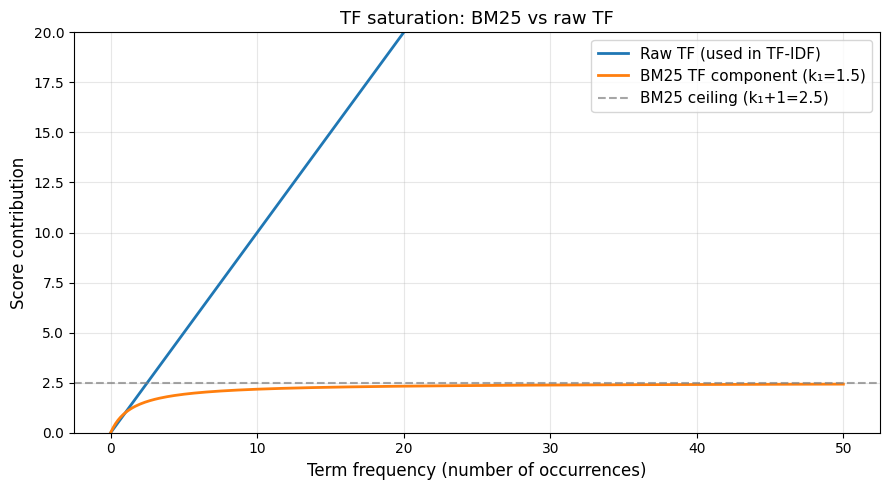

In [31]:
import matplotlib.pyplot as plt

tf_range = np.linspace(0, 50, 300)
k1 = 1.5

raw_tf = tf_range
bm25_tf = (tf_range * (k1 + 1)) / (tf_range + k1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tf_range, raw_tf, label='Raw TF (used in TF-IDF)', linewidth=2)
ax.plot(tf_range, bm25_tf, label=f'BM25 TF component (k₁={k1})', linewidth=2)
ax.axhline(k1 + 1, color='gray', linestyle='--', alpha=0.7, label=f'BM25 ceiling (k₁+1={k1+1})')
ax.set_xlabel('Term frequency (number of occurrences)', fontsize=12)
ax.set_ylabel('Score contribution', fontsize=12)
ax.set_title('TF saturation: BM25 vs raw TF', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0, 20)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
from rank_bm25 import BM25Okapi

corpus = [
    "the cat sat on the mat",
    "the dog chased the cat around the garden",
    "neural networks learn representations of data",
    "deep learning uses neural networks with many layers",
    "the cat and dog are domestic animals that people love",
]

tokenized_corpus = [doc.lower().split() for doc in corpus]
bm25 = BM25Okapi(tokenized_corpus)

query = "cat"
scores = bm25.get_scores(query.lower().split())

print(f"Query: '{query}'")
print()
ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
for rank, (idx, score) in enumerate(ranked, 1):
    print(f"  Rank {rank} (score={score:.3f}): {corpus[idx]}")

Query: 'cat'

  Rank 1 (score=0.253): the cat sat on the mat
  Rank 2 (score=0.223): the dog chased the cat around the garden
  Rank 3 (score=0.200): the cat and dog are domestic animals that people love
  Rank 4 (score=0.000): neural networks learn representations of data
  Rank 5 (score=0.000): deep learning uses neural networks with many layers


In [33]:
# Multi-term query
query = "cat dog"
scores = bm25.get_scores(query.lower().split())

print(f"Query: '{query}'")
print()
ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
for rank, (idx, score) in enumerate(ranked, 1):
    print(f"  Rank {rank} (score={score:.3f}): {corpus[idx]}")

Query: 'cat dog'

  Rank 1 (score=0.552): the dog chased the cat around the garden
  Rank 2 (score=0.495): the cat and dog are domestic animals that people love
  Rank 3 (score=0.253): the cat sat on the mat
  Rank 4 (score=0.000): neural networks learn representations of data
  Rank 5 (score=0.000): deep learning uses neural networks with many layers


In [34]:
# BM25 vs TF-IDF: head-to-head on same corpus
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(corpus)

query_vec = tfidf.transform(["cat dog"])
tfidf_scores = cosine_similarity(query_vec, tfidf_matrix)[0]

bm25_scores = bm25.get_scores("cat dog".split())

print(f"{'Document':<52} {'TF-IDF':>8} {'BM25':>8}")
print("-" * 70)
for i, doc in enumerate(corpus):
    short = doc[:50]
    print(f"{short:<52} {tfidf_scores[i]:>8.3f} {bm25_scores[i]:>8.3f}")

Document                                               TF-IDF     BM25
----------------------------------------------------------------------
the cat sat on the mat                                  0.187    0.253
the dog chased the cat around the garden                0.368    0.552
neural networks learn representations of data           0.000    0.000
deep learning uses neural networks with many layer      0.000    0.000
the cat and dog are domestic animals that people l      0.359    0.495


In [35]:
# BM25 parameters: effect of k1 and b
print("Effect of k1 (TF saturation speed):")
print(f"  k1=0.5 → saturates very fast (almost binary: present/absent)")
print(f"  k1=1.2 → moderate saturation (common default)")
print(f"  k1=2.0 → slower saturation (rewards repeated terms more)")
print()
print("Effect of b (length normalization):")
print(f"  b=0.0  → no length normalization (long docs always win)")
print(f"  b=0.75 → partial normalization (common default)")
print(f"  b=1.0  → full normalization (score purely by density, not count)")
print()

query = "cat"
for k1 in [0.5, 1.2, 2.0]:
    bm = BM25Okapi(tokenized_corpus, k1=k1, b=0.75)
    scores = bm.get_scores(query.split())
    best_idx = int(np.argmax(scores))
    print(f"  k1={k1}: top doc → '{corpus[best_idx][:50]}' (score={scores[best_idx]:.3f})")

Effect of k1 (TF saturation speed):
  k1=0.5 → saturates very fast (almost binary: present/absent)
  k1=1.2 → moderate saturation (common default)
  k1=2.0 → slower saturation (rewards repeated terms more)

Effect of b (length normalization):
  b=0.0  → no length normalization (long docs always win)
  b=0.75 → partial normalization (common default)
  b=1.0  → full normalization (score purely by density, not count)

  k1=0.5: top doc → 'the cat sat on the mat' (score=0.241)
  k1=1.2: top doc → 'the cat sat on the mat' (score=0.250)
  k1=2.0: top doc → 'the cat sat on the mat' (score=0.256)


### 6.4 BoW / TF-IDF / BM25 limitations — and what comes next

In [36]:
# Limitation 1: no word order
corpus_order = ["dog bites man", "man bites dog"]
v = CountVectorizer()
m = v.fit_transform(corpus_order).toarray()
print("No word order (BoW):")
print(f"  '{corpus_order[0]}' → {m[0]}")
print(f"  '{corpus_order[1]}' → {m[1]}")
print(f"  Identical? {np.array_equal(m[0], m[1])}")
print()

# Limitation 2: no semantics
tfidf2 = TfidfVectorizer()
vecs = tfidf2.fit_transform(["happy", "joyful", "sad"]).toarray()
sim_happy_joyful = cosine_similarity([vecs[0]], [vecs[1]])[0][0]
sim_happy_sad = cosine_similarity([vecs[0]], [vecs[2]])[0][0]
print("No semantics (TF-IDF):")
print(f"  cosine('happy', 'joyful') = {sim_happy_joyful:.3f}  ← synonyms look unrelated")
print(f"  cosine('happy', 'sad')    = {sim_happy_sad:.3f}  ← antonyms also unrelated")
print()

# Limitation 3: sparsity
tfidf3 = TfidfVectorizer()
matrix3 = tfidf3.fit_transform(corpus)
density = matrix3.nnz / (matrix3.shape[0] * matrix3.shape[1])
print(f"Sparsity:")
print(f"  Matrix shape: {matrix3.shape}")
print(f"  Non-zero entries: {matrix3.nnz} out of {matrix3.shape[0] * matrix3.shape[1]}")
print(f"  Density: {density:.1%}  ← {100 - density*100:.1f}% zeros")

No word order (BoW):
  'dog bites man' → [1 1 1]
  'man bites dog' → [1 1 1]
  Identical? True

No semantics (TF-IDF):
  cosine('happy', 'joyful') = 0.000  ← synonyms look unrelated
  cosine('happy', 'sad')    = 0.000  ← antonyms also unrelated

Sparsity:
  Matrix shape: (5, 28)
  Non-zero entries: 35 out of 140
  Density: 25.0%  ← 75.0% zeros


In [37]:
# Summary: when to use what
print("Method comparison:")
print()
methods = [
    ("BoW",     "Simple count",              "Baseline text classification, simple search"),
    ("TF-IDF",  "Weighted by rarity",        "Document retrieval, keyword extraction"),
    ("BM25",    "Saturated TF + length norm","Production search engines, RAG retrieval"),
    ("Embeddings", "Dense semantic vectors", "Semantic search, similarity, next lecture"),
]
print(f"{'Method':<12} {'Key idea':<30} {'Best use case'}")
print("-" * 80)
for method, idea, use in methods:
    print(f"{method:<12} {idea:<30} {use}")

Method comparison:

Method       Key idea                       Best use case
--------------------------------------------------------------------------------
BoW          Simple count                   Baseline text classification, simple search
TF-IDF       Weighted by rarity             Document retrieval, keyword extraction
BM25         Saturated TF + length norm     Production search engines, RAG retrieval
Embeddings   Dense semantic vectors         Semantic search, similarity, next lecture


---
## Part 7 — Classification comparison: BoW vs TF-IDF vs BM25

**Task:** 20 Newsgroups — classify news posts into 4 topic categories.

We compare three approaches:
1. **BoW + Multinomial Naive Bayes** — the classic baseline
2. **TF-IDF + Logistic Regression** — TF-IDF as features
3. **BM25 + Nearest-neighbor vote** — retrieval-based classifier

For BM25: each test document is scored against all training documents,
scores are summed per class, and the document is assigned to the highest-scoring class.

In [34]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from rank_bm25 import BM25Okapi
import numpy as np
import re
import time

categories = [
    "sci.med",
    "sci.space",
    "rec.sport.hockey",
    "talk.politics.guns",
]

train = fetch_20newsgroups(subset="train", categories=categories,
                           remove=("headers", "footers", "quotes"))
test  = fetch_20newsgroups(subset="test",  categories=categories,
                           remove=("headers", "footers", "quotes"))

print(f"Training documents : {len(train.data)}")
print(f"Test documents     : {len(test.data)}")
print(f"Categories         : {train.target_names}")
print()
for i, cat in enumerate(train.target_names):
    n = sum(train.target == i)
    print(f"  {cat:<30} {n} training docs")

Training documents : 2333
Test documents     : 1553
Categories         : ['rec.sport.hockey', 'sci.med', 'sci.space', 'talk.politics.guns']

  rec.sport.hockey               600 training docs
  sci.med                        594 training docs
  sci.space                      593 training docs
  talk.politics.guns             546 training docs


In [35]:
# Peek at one document
inx = 1
print(f"Category: {train.target_names[train.target[inx]]}")
print()
print(train.data[inx][:500])

Category: rec.sport.hockey

 
 
 Well, I'm a Wings fan and I think the FIRST thing that you should do is to
get the opponent's line combinations correct before you try to match up anyone
with them.  There is no Yzerman-Fedorov-Probert line, except for maybe on a
powerplay.  These three players usually play on three different lines.
Which would mean that Toronto's checking line would have to pull a triple
shift.
The Wings' lines usually look like this:
 
                      Gallant-Yzerman-Ciccarelli
 
                   


## Preprocessing

Remove punctuation and stop words from the text data for consistent preprocessing across all methods.

In [36]:
import string
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Lowercase and split
    words = text.lower().split()
    # Remove stop words
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

# Apply preprocessing
train.data = [preprocess_text(doc) for doc in train.data]
test.data = [preprocess_text(doc) for doc in test.data]

print("Preprocessing completed: punctuation and stop words removed.")

Preprocessing completed: punctuation and stop words removed.


### Method 1: BoW + Multinomial Naive Bayes

In [43]:
t0 = time.time()

bow_vec = CountVectorizer(stop_words="english", min_df=2)
X_train_bow = bow_vec.fit_transform(train.data)
X_test_bow  = bow_vec.transform(test.data)

# nb = MultinomialNB()
# nb.fit(X_train_bow, train.target)
# pred_bow = nb.predict(X_test_bow)

lr = LogisticRegression(random_state=42)
lr.fit(X_train_bow, train.target)
pred_bow = lr.predict(X_test_bow)

acc_bow = accuracy_score(test.target, pred_bow)
time_bow = time.time() - t0

print(f"BoW + Logistic Regression results:")
print(f"  Accuracy : {acc_bow:.3f}")
print(f"  Time     : {time_bow:.2f}s")
print(f"  Features : {X_train_bow.shape[1]:,} dimensions")

BoW + Logistic Regression results:
  Accuracy : 0.821
  Time     : 1.96s
  Features : 15,323 dimensions


### BoW Feature Analysis

In [38]:
print(f"BoW Vocabulary size: {len(bow_vec.vocabulary_)} words")

# Get top words by frequency
word_freq = X_train_bow.sum(axis=0).A1  # sum over documents
top_indices = word_freq.argsort()[-10:][::-1]  # top 10
feature_names = bow_vec.get_feature_names_out()
top_words = [feature_names[i] for i in top_indices]
top_freqs = [word_freq[i] for i in top_indices]

print("Top 10 words by frequency:")
for word, freq in zip(top_words, top_freqs):
    print(f"  {word}: {freq}")

BoW Vocabulary size: 15323 words
Top 10 words by frequency:
  space: 844
  people: 818
  dont: 778
  like: 771
  time: 665
  think: 644
  new: 592
  know: 589
  use: 538
  gun: 520


In [39]:
t0 = time.time()

lr_bow = LogisticRegression(max_iter=1000, C=5)
lr_bow.fit(X_train_bow, train.target)
pred_lr_bow = lr_bow.predict(X_test_bow)

acc_lr_bow = accuracy_score(test.target, pred_lr_bow)
time_lr_bow = time.time() - t0

print(f"BoW + Logistic Regression")
print(f"  Accuracy : {acc_lr_bow:.3f}")
print(f"  Time     : {time_lr_bow:.2f}s")

BoW + Logistic Regression
  Accuracy : 0.812
  Time     : 0.28s


### Method 2: TF-IDF + Logistic Regression

In [44]:
t0 = time.time()

tfidf_vec = TfidfVectorizer(stop_words="english", min_df=2, sublinear_tf=True)
X_train_tfidf = tfidf_vec.fit_transform(train.data)
X_test_tfidf  = tfidf_vec.transform(test.data)

# Explain and inspect TF, IDF, TF-IDF for a sample of terms
print("\nTF-IDF details (sample terms):")
feature_names = tfidf_vec.get_feature_names_out()

# Choose a sample document and terms
sample_doc_idx = 0
sample_terms = [feature_names[i] for i in [0, 1, 2, 3, 4]]

# Compute TF for sample document in raw (non-normalized) frequencies
doc_counts = X_train_tfidf[sample_doc_idx].toarray().flatten()

for term in sample_terms:
    term_idx = tfidf_vec.vocabulary_.get(term)
    tf_value = doc_counts[term_idx] if term_idx is not None else 0
    idf_value = tfidf_vec.idf_[term_idx] if term_idx is not None else 0
    tfidf_value = X_train_tfidf[sample_doc_idx, term_idx] if term_idx is not None else 0
    print(f"  term='{term}' | tf={tf_value:.3f} | idf={idf_value:.3f} | tf-idf={tfidf_value:.3f}")

# Since TfidfVectorizer returns normalized TF-IDF vectors, final values involve term frequency weighted by inverse document frequency.
# TF: frequency of term in this document (here as normalized in the sparse matrix).
# IDF: log(1 + n_documents / (1 + doc_freq(term))) + 1 (sklearn smoothing)
# TF-IDF: tf * idf for each term in document.

lr = LogisticRegression(max_iter=1000, C=5)
lr.fit(X_train_tfidf, train.target)
pred_tfidf = lr.predict(X_test_tfidf)

acc_tfidf = accuracy_score(test.target, pred_tfidf)
time_tfidf = time.time() - t0

print(f"\nTF-IDF + Logistic Regression")
print(f"  Accuracy : {acc_tfidf:.3f}")
print(f"  Time     : {time_tfidf:.2f}s")
print(f"  Features : {X_train_tfidf.shape[1]:,} dimensions")


TF-IDF details (sample terms):
  term='00' | tf=0.000 | idf=5.922 | tf-idf=0.000
  term='000' | tf=0.000 | idf=6.676 | tf-idf=0.000
  term='000000' | tf=0.000 | idf=7.657 | tf-idf=0.000
  term='00041032' | tf=0.000 | idf=7.657 | tf-idf=0.000
  term='0004422' | tf=0.000 | idf=7.657 | tf-idf=0.000

TF-IDF + Logistic Regression
  Accuracy : 0.869
  Time     : 1.97s
  Features : 15,323 dimensions


### TF-IDF Feature Analysis

In [41]:
print(f"TF-IDF Vocabulary size: {len(tfidf_vec.vocabulary_)} words")

# Get top words by sum of TF-IDF scores
tfidf_sum = X_train_tfidf.sum(axis=0).A1
top_indices = tfidf_sum.argsort()[-10:][::-1]
feature_names = tfidf_vec.get_feature_names_out()
top_words = [feature_names[i] for i in top_indices]
top_scores = [tfidf_sum[i] for i in top_indices]

print("Top 10 words by TF-IDF sum:")
for word, score in zip(top_words, top_scores):
    print(f"  {word}: {score:.2f}")

TF-IDF Vocabulary size: 15323 words
Top 10 words by TF-IDF sum:
  dont: 36.53
  like: 35.52
  know: 33.42
  think: 32.71
  people: 31.68
  time: 26.50
  good: 25.98
  im: 25.54
  space: 21.86
  game: 21.66


### Method 3: BM25 + weighted nearest-neighbor vote

For each test document, compute BM25 similarity to every training document.
Sum scores per class and pick the highest — a retrieval-based classifier.

In [42]:
t0 = time.time()

import nltk
from nltk.corpus import stopwords as nltk_sw
nltk.download("stopwords", quiet=True)
sw = set(nltk_sw.words("english"))

def tokenize_for_bm25(text):
    tokens = re.sub(r"[^\w\s]", " ", text.lower()).split()
    return [t for t in tokens if t not in sw and len(t) > 1]

tokenized_train = [tokenize_for_bm25(doc) for doc in train.data]
tokenized_test  = [tokenize_for_bm25(doc) for doc in test.data]

bm25_clf = BM25Okapi(tokenized_train)
n_classes = len(categories)

pred_bm25 = []
for query_tokens in tokenized_test:
    scores = bm25_clf.get_scores(query_tokens)       # score vs all train docs
    class_scores = np.zeros(n_classes)
    for doc_idx, score in enumerate(scores):         # sum scores per class
        class_scores[train.target[doc_idx]] += score
    pred_bm25.append(int(np.argmax(class_scores)))

acc_bm25 = accuracy_score(test.target, pred_bm25)
time_bm25 = time.time() - t0

print(f"BM25 + nearest-neighbor vote")
print(f"  Accuracy : {acc_bm25:.3f}")
print(f"  Time     : {time_bm25:.2f}s")
print(f"  No feature matrix — retrieval-based")

BM25 + nearest-neighbor vote
  Accuracy : 0.853
  Time     : 110.80s
  No feature matrix — retrieval-based


### BM25 Feature Analysis

In [30]:
# Collect all unique tokens
all_tokens = set()
for tokens in tokenized_train:
    all_tokens.update(tokens)
vocab_size = len(all_tokens)
print(f"BM25 Vocabulary size: {vocab_size} unique tokens")

# Top words by frequency
from collections import Counter
token_counts = Counter()
for tokens in tokenized_train:
    token_counts.update(tokens)
top_tokens = token_counts.most_common(10)
print("Top 10 tokens by frequency:")
for token, count in top_tokens:
    print(f"  {token}: {count}")

BM25 Vocabulary size: 36347 unique tokens
Top 10 tokens by frequency:
  would: 1455
  one: 1211
  space: 844
  people: 818
  dont: 778
  like: 771
  get: 767
  also: 709
  time: 665
  think: 644


In [31]:
# Create BM25 feature matrices
X_train_bm25 = np.array([bm25_clf.get_scores(tokens) for tokens in tokenized_train])
X_test_bm25 = np.array([bm25_clf.get_scores(tokens) for tokens in tokenized_test])

print(f"BM25 features shape: {X_train_bm25.shape}")

# Logistic Regression on BM25 features
t0 = time.time()
lr_bm25 = LogisticRegression(max_iter=1000, C=5)
lr_bm25.fit(X_train_bm25, train.target)
pred_lr_bm25 = lr_bm25.predict(X_test_bm25)

acc_lr_bm25 = accuracy_score(test.target, pred_lr_bm25)
time_lr_bm25 = time.time() - t0

print(f"BM25 + Logistic Regression")
print(f"  Accuracy : {acc_lr_bm25:.3f}")
print(f"  Time     : {time_lr_bm25:.2f}s")

BM25 features shape: (2333, 2333)
BM25 + Logistic Regression
  Accuracy : 0.853
  Time     : 0.35s


### Comparison of Logistic Regression across Representations

In [32]:
import pandas as pd

results = {
    'Representation': ['BoW', 'TF-IDF', 'BM25'],
    'Accuracy': [acc_lr_bow, acc_tfidf, acc_lr_bm25],
    'Time (s)': [time_lr_bow, time_tfidf, time_lr_bm25],
    'Features': [X_train_bow.shape[1], X_train_tfidf.shape[1], X_train_bm25.shape[1]]
}

df = pd.DataFrame(results)
print(df)

  Representation  Accuracy  Time (s)  Features
0            BoW  0.811977  1.083610     15323
1         TF-IDF  0.868641  1.854971     15323
2           BM25  0.852543  0.352116      2333


### Results comparison

In [33]:
print(f"Method                              Accuracy     Time")
print("-" * 55)
print(f"BoW + Naive Bayes                  {acc_bow:.3f}    {time_bow:.2f}s")
print(f"TF-IDF + Logistic Regression       {acc_tfidf:.3f}    {time_tfidf:.2f}s")
print(f"BM25 + NN vote                     {acc_bm25:.3f}    {time_bm25:.2f}s")

Method                              Accuracy     Time
-------------------------------------------------------
BoW + Naive Bayes                  0.882    0.31s
TF-IDF + Logistic Regression       0.869    1.85s
BM25 + NN vote                     0.853    135.65s


In [34]:
# Per-class breakdown
import pandas as pd
short_names = ["sci.med", "sci.space", "hockey", "politics.guns"]

for method_name, preds in [("BoW+NB", pred_bow),
                            ("TF-IDF+LR", pred_tfidf),
                            ("BM25+NN", pred_bm25)]:
    report = classification_report(test.target, preds,
                                   target_names=short_names,
                                   output_dict=True)
    print(f"\n--- {method_name} ---")
    for cat in short_names:
        r = report[cat]
        print(f"  {cat:<18} precision={r['precision']:.2f}  recall={r['recall']:.2f}  f1={r['f1-score']:.2f}")


--- BoW+NB ---
  sci.med            precision=0.87  recall=0.91  f1=0.89
  sci.space          precision=0.91  recall=0.88  f1=0.89
  hockey             precision=0.93  recall=0.85  f1=0.89
  politics.guns      precision=0.82  recall=0.89  f1=0.85

--- TF-IDF+LR ---
  sci.med            precision=0.97  recall=0.90  f1=0.93
  sci.space          precision=0.86  recall=0.86  f1=0.86
  hockey             precision=0.79  recall=0.88  f1=0.83
  politics.guns      precision=0.87  recall=0.83  f1=0.85

--- BM25+NN ---
  sci.med            precision=0.86  recall=0.93  f1=0.90
  sci.space          precision=0.84  recall=0.85  f1=0.85
  hockey             precision=0.94  recall=0.74  f1=0.83
  politics.guns      precision=0.79  recall=0.88  f1=0.83


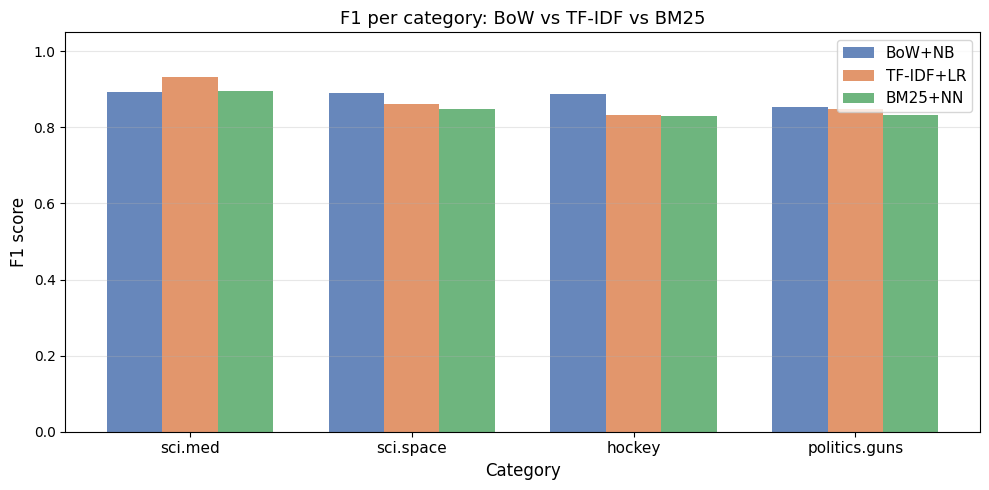

In [35]:
import matplotlib.pyplot as plt

methods  = ["BoW+NB", "TF-IDF+LR", "BM25+NN"]
all_preds = [pred_bow, pred_tfidf, pred_bm25]
colors   = ["#4C72B0", "#DD8452", "#55A868"]

f1_data = {}
for name, preds in zip(methods, all_preds):
    report = classification_report(test.target, preds,
                                   target_names=short_names, output_dict=True)
    f1_data[name] = [report[c]["f1-score"] for c in short_names]

x = np.arange(len(short_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (method, color) in enumerate(zip(methods, colors)):
    ax.bar(x + i * width, f1_data[method], width, label=method, color=color, alpha=0.85)

ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("F1 score", fontsize=12)
ax.set_title("F1 per category: BoW vs TF-IDF vs BM25", fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# Top discriminative words per category (TF-IDF + LR coefficients)
feature_names = tfidf_vec.get_feature_names_out()

print("Top TF-IDF features per category (by LR coefficient):")
for class_idx, cat in enumerate(short_names):
    coef = lr.coef_[class_idx]
    top_idx = np.argsort(coef)[-10:][::-1]
    top_words = [f"{feature_names[i]}({coef[i]:.2f})" for i in top_idx]
    print(f"  {cat:<18} {', '.join(top_words)}")

Top TF-IDF features per category (by LR coefficient):
  sci.med            hockey(5.28), game(4.98), team(4.88), games(3.55), season(3.16), players(3.13), play(3.12), nhl(3.03), teams(2.82), mask(2.79)
  sci.space          msg(3.26), doctor(3.08), disease(3.07), medical(2.78), pain(2.49), treatment(2.47), health(2.45), patients(2.30), cancer(2.18), information(2.12)
  hockey             space(7.34), orbit(3.46), nasa(3.06), earth(2.97), moon(2.93), launch(2.91), spacecraft(2.38), shuttle(2.32), scispace(2.17), program(2.08)
  politics.guns      gun(5.56), guns(3.88), weapons(3.87), fbi(3.20), law(3.04), government(2.63), firearms(2.62), jmdhandheldcom(2.50), batf(2.43), weapon(2.37)


In [37]:
# A misclassified example — what fooled the model?
errors = [(i, test.target[i], pred_tfidf[i])
          for i in range(len(test.data))
          if test.target[i] != pred_tfidf[i]]

print(f"Total TF-IDF errors: {len(errors)} / {len(test.data)} ({len(errors)/len(test.data):.1%})")
print()
if errors:
    idx, true_label, pred_label = errors[0]
    print(f"Example misclassification:")
    print(f"  True      : {short_names[true_label]}")
    print(f"  Predicted : {short_names[pred_label]}")
    print(f"\nDocument (first 400 chars):")
    print(test.data[idx][:400])

Total TF-IDF errors: 204 / 1553 (13.1%)

Example misclassification:
  True      : politics.guns
  Predicted : sci.space

Document (first 400 chars):
youre guy doesnt know illiterate people cant write coherent sentences make superior somehow steve


### Key takeaways from the comparison

- **BoW + Naive Bayes** is fast and strong on topic classification — raw counts work because category words are distinctive by nature
- **TF-IDF + LR** outperforms BoW because IDF downweights common cross-category words and amplifies rare but discriminative ones
- **BM25 + NN** is a retrieval-based classifier with no training step — it underperforms here because BM25 was designed for **ranking**, not classification

> **Rule of thumb:**
> - Classification → TF-IDF features + trained classifier
> - Retrieval / RAG → BM25 as the lexical baseline
>
> Modern RAG systems often combine both: BM25 retrieves candidates, a neural re-ranker refines the order.

## Embedding visualization: BoW vs TF-IDF
Use t-SNE to project BoW and TF-IDF feature vectors into two dimensions and color each sample by its true topic label.


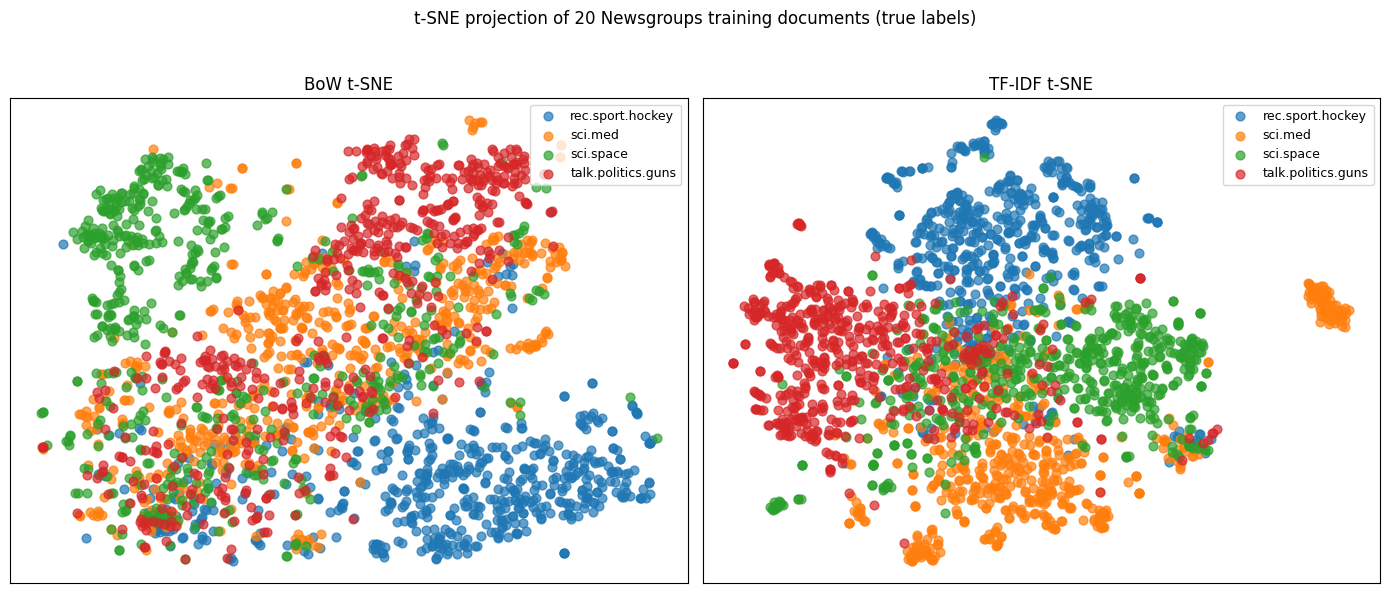

In [46]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce sparse feature matrices before running t-SNE
svd_bow = TruncatedSVD(n_components=50, random_state=42)
svd_tfidf = TruncatedSVD(n_components=50, random_state=42)
X_bow_reduced = svd_bow.fit_transform(X_train_bow)
X_tfidf_reduced = svd_tfidf.fit_transform(X_train_tfidf)
X_bow_2d = TSNE(n_components=2, init="pca", random_state=42, learning_rate="auto").fit_transform(X_bow_reduced)
X_tfidf_2d = TSNE(n_components=2, init="pca", random_state=42, learning_rate="auto").fit_transform(X_tfidf_reduced)
label_names = train.target_names
palette = sns.color_palette("tab10", n_colors=len(label_names))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, X_2d, title in zip(axes, [X_bow_2d, X_tfidf_2d], ["BoW t-SNE", "TF-IDF t-SNE"]):
    for cls_idx, cls_name in enumerate(label_names):
        mask = train.target == cls_idx
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=40, alpha=0.7, color=palette[cls_idx], label=cls_name)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(fontsize=9)
plt.suptitle("t-SNE projection of 20 Newsgroups training documents (true labels)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


---
## Part 8 — Sentiment analysis: BoW vs TF-IDF vs BM25

**Task:** Twitter sentiment — classify tweets as positive or negative.

**Dataset:** NLTK `twitter_samples` — 5,000 positive + 5,000 negative tweets, balanced.

This task is deliberately different from topic classification:
- Topic classification is driven by **rare, distinctive nouns** (space, surgery, hockey)
- Sentiment is driven by **common opinion words** (good, bad, love, hate) that appear across all documents
- TF-IDF's IDF penalty may actually *hurt* here — sentiment words are frequent everywhere

We also add **Twitter-specific preprocessing**: removing @mentions, URLs, and handling hashtags.

In [38]:
import nltk
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from rank_bm25 import BM25Okapi
import time

nltk.download("twitter_samples", quiet=True)
nltk.download("stopwords", quiet=True)
from nltk.corpus import twitter_samples
from nltk.corpus import stopwords as nltk_sw

pos_tweets = twitter_samples.strings("positive_tweets.json")
neg_tweets = twitter_samples.strings("negative_tweets.json")

texts  = pos_tweets + neg_tweets
labels = [1] * len(pos_tweets) + [0] * len(neg_tweets)

print(f"Total tweets  : {len(texts)}")
print(f"Positive      : {sum(labels)}")
print(f"Negative      : {len(labels) - sum(labels)}")
print()
print("Sample positive:", pos_tweets[0])
print("Sample negative:", neg_tweets[0])

Total tweets  : 10000
Positive      : 5000
Negative      : 5000

Sample positive: #FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :)
Sample negative: hopeless for tmr :(


### Twitter-specific preprocessing

In [ ]:
def preprocess_tweet(text):
    """Twitter-specific cleaning pipeline."""
    text = re.sub(r"http\S+|www\.\S+", "", text)      # remove URLs
    text = re.sub(r"@\w+", "", text)                   # remove @mentions
    text = re.sub(r"#(\w+)", r"\1", text)             # keep hashtag text, drop #
    text = re.sub(r"[^\w\s]", " ", text)              # remove punctuation
    text = re.sub(r"\s+", " ", text).strip().lower()   # normalize whitespace
    return text

examples = [
    "#FollowFriday @France_Inte @PKuchly57 for being top members :)",
    "I HATE this https://t.co/abc123 so much!!! it's the worst",
    "@someone feeling great today! #happy #blessed",
]
print("Before -> After preprocessing:")
for tweet in examples:
    print(f"  IN : {tweet}")
    print(f"  OUT: {preprocess_tweet(tweet)}")
    print()

cleaned_texts = [preprocess_tweet(t) for t in texts]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    cleaned_texts, labels, test_size=0.2, random_state=42, stratify=labels
)
print(f"Training: {len(X_train)} tweets")
print(f"Test    : {len(X_test)} tweets")
print(f"Balance in test -- positive: {sum(y_test)}, negative: {len(y_test)-sum(y_test)}")

### Method 1: BoW + Multinomial Naive Bayes

In [ ]:
t0 = time.time()
bow_vec_s = CountVectorizer(ngram_range=(1, 2), min_df=3)
X_train_bow_s = bow_vec_s.fit_transform(X_train)
X_test_bow_s  = bow_vec_s.transform(X_test)
nb_s = MultinomialNB()
nb_s.fit(X_train_bow_s, y_train)
pred_bow_s = nb_s.predict(X_test_bow_s)
acc_bow_s  = accuracy_score(y_test, pred_bow_s)
time_bow_s = time.time() - t0
print(f"BoW (1+2-gram) + Naive Bayes")
print(f"  Accuracy : {acc_bow_s:.3f}  |  Time: {time_bow_s:.2f}s  |  Features: {X_train_bow_s.shape[1]:,}")
print()
print(classification_report(y_test, pred_bow_s, target_names=["negative", "positive"]))

### Method 2: TF-IDF + Logistic Regression

In [ ]:
t0 = time.time()
# sublinear_tf=False: for sentiment, word repetition IS signal
tfidf_vec_s = TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=False)
X_train_tfidf_s = tfidf_vec_s.fit_transform(X_train)
X_test_tfidf_s  = tfidf_vec_s.transform(X_test)
lr_s = LogisticRegression(max_iter=1000, C=5)
lr_s.fit(X_train_tfidf_s, y_train)
pred_tfidf_s = lr_s.predict(X_test_tfidf_s)
acc_tfidf_s  = accuracy_score(y_test, pred_tfidf_s)
time_tfidf_s = time.time() - t0
print(f"TF-IDF (1+2-gram) + Logistic Regression")
print(f"  Accuracy : {acc_tfidf_s:.3f}  |  Time: {time_tfidf_s:.2f}s  |  Features: {X_train_tfidf_s.shape[1]:,}")
print()
print(classification_report(y_test, pred_tfidf_s, target_names=["negative", "positive"]))

### Method 3: BM25 + weighted nearest-neighbor vote

In [ ]:
t0 = time.time()
sw = set(nltk_sw.words("english"))

def tokenize_tweet(text):
    return [t for t in text.split() if t not in sw and len(t) > 1]

tok_train = [tokenize_tweet(t) for t in X_train]
tok_test  = [tokenize_tweet(t) for t in X_test]
y_train_arr = np.array(y_train)

bm25_s = BM25Okapi(tok_train)
pred_bm25_s = []
for query_tokens in tok_test:
    scores = bm25_s.get_scores(query_tokens)
    class_scores = np.zeros(2)
    for doc_idx, score in enumerate(scores):
        class_scores[y_train_arr[doc_idx]] += score
    pred_bm25_s.append(int(np.argmax(class_scores)))

acc_bm25_s  = accuracy_score(y_test, pred_bm25_s)
time_bm25_s = time.time() - t0
print(f"BM25 + nearest-neighbor vote")
print(f"  Accuracy : {acc_bm25_s:.3f}  |  Time: {time_bm25_s:.2f}s")
print()
print(classification_report(y_test, pred_bm25_s, target_names=["negative", "positive"]))

### Results summary and comparison with topic classification

In [ ]:
import matplotlib.pyplot as plt

methods_labels = ["BoW+NB", "TF-IDF+LR", "BM25+NN"]
acc_sentiment  = [acc_bow_s, acc_tfidf_s, acc_bm25_s]
acc_topic      = [acc_bow,   acc_tfidf,   acc_bm25]

x = np.arange(len(methods_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, acc_topic,     width, label="Topic (20 newsgroups)", color="#4C72B0", alpha=0.85)
bars2 = ax.bar(x + width/2, acc_sentiment, width, label="Sentiment (Twitter)",   color="#DD8452", alpha=0.85)

ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Topic classification vs sentiment analysis", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(methods_labels, fontsize=12)
ax.set_ylim(0.5, 1.05)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
for bar in list(bars1) + list(bars2):
    ax.annotate(f"{bar.get_height():.3f}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Top positive and negative words learned by the model
feature_names_s = tfidf_vec_s.get_feature_names_out()
coef = lr_s.coef_[0]

top_pos_idx = np.argsort(coef)[-15:][::-1]
top_neg_idx = np.argsort(coef)[:15]

print("Top POSITIVE features (TF-IDF+LR coefficients):")
for i in top_pos_idx:
    print(f"  {feature_names_s[i]:<25} {coef[i]:+.3f}")

print()
print("Top NEGATIVE features (TF-IDF+LR coefficients):")
for i in top_neg_idx:
    print(f"  {feature_names_s[i]:<25} {coef[i]:+.3f}")

In [ ]:
# Negation challenge: does the model handle "not good"?
negation_tweets = [
    "i do not like this at all",
    "this is not good",
    "not bad actually pretty good",
    "i love it so much",
    "i hate everything today",
]

print("Negation and sentiment predictions (TF-IDF+LR):")
print(f"  {'Tweet':<40} Predicted")
print("-" * 60)
for tweet in negation_tweets:
    cleaned = preprocess_tweet(tweet)
    vec = tfidf_vec_s.transform([cleaned])
    pred = lr_s.predict(vec)[0]
    label = "POSITIVE" if pred == 1 else "NEGATIVE"
    print(f"  {tweet:<40} {label}")

In [ ]:
# Are negation bigrams in the vocabulary and correctly signed?
negation_bigrams = ["not good", "not bad", "not like", "not great", "not happy", "so good", "so bad"]
print("Negation bigrams in vocabulary:")
for bigram in negation_bigrams:
    if bigram in tfidf_vec_s.vocabulary_:
        idx = tfidf_vec_s.vocabulary_[bigram]
        sign = "positive" if coef[idx] > 0 else "negative"
        print(f"  '{bigram}': coeff={coef[idx]:+.3f} -> {sign}")
    else:
        print(f"  '{bigram}': NOT in vocabulary (too rare in training data)")

In [ ]:
# IDF scores: why sentiment words are penalized
idf_lookup = dict(zip(tfidf_vec_s.get_feature_names_out(), tfidf_vec_s.idf_))

sentiment_words = ["love", "hate", "great", "terrible", "happy", "sad", "good", "bad", "awesome", "horrible"]
print("IDF of core sentiment words (lower = more common = penalized more):")
for word in sentiment_words:
    if word in idf_lookup:
        print(f"  {word:<12} IDF = {idf_lookup[word]:.3f}")

print()
# Compare to topic-specific words
topic_words_in_tweets = [w for w in ["nasa", "surgery", "hockey", "gun", "space"] if w in idf_lookup]
print("IDF of topic-specific words for comparison:")
for word in topic_words_in_tweets:
    print(f"  {word:<12} IDF = {idf_lookup[word]:.3f}")

print()
print("=> Sentiment words have LOW IDF (common everywhere) -> TF-IDF downweights exactly the words that matter most")

### Key takeaways

**Why sentiment is harder than topic classification for these methods:**
- Sentiment words ("good", "bad", "love", "hate") appear in **both** positive and negative documents
  — their IDF is low, so TF-IDF penalizes the words that matter most
- Topic words ("surgery", "nasa", "hockey") are rare outside their category
  — IDF amplifies them, which is exactly what we want

**Bigrams help, but only partially:**
- `"not good"` as a bigram captures negation that separate unigrams cannot
- But rare negation patterns may not appear enough times in training to make it into the vocabulary (`min_df=3`)

**BM25 on sentiment:**
- TF saturation hurts: repeated emotional words ("love love love") carry genuine emphasis in tweets
- Retrieval-based classification struggles because tweets from the same sentiment class are topically diverse

> **Bottom line:** for sentiment analysis, classical methods top out around 75-80% on Twitter data.  
> The real leap comes from **transformer models** (BERT, RoBERTa, BERTweet) that understand  
> context, negation, and sarcasm through attention — which is the topic of a future lecture.

---
## Summary

We covered the full low-level NLP preprocessing pipeline:

| Step | Tools |
|---|---|
| Cleaning & normalization | `re`, `unicodedata`, `BeautifulSoup` |
| Stop words | `nltk.corpus.stopwords` |
| Stemming | `nltk.stem.PorterStemmer`, `SnowballStemmer` |
| Lemmatization | `spacy` |
| N-grams | `nltk.ngrams` |
| Word tokenization | `nltk.word_tokenize`, `sent_tokenize` |
| Subword tokenization | `transformers` (GPT-2 BPE, BERT WordPiece, T5 SentencePiece) |
| Bag of words | `sklearn.CountVectorizer` |
| TF-IDF | `sklearn.TfidfVectorizer` |
| BM25 | `rank_bm25.BM25Okapi` |

**Next lecture:** Word embeddings — dense, semantic vector representations that solve the sparsity and semantics limitations we saw here.